<a href="https://colab.research.google.com/github/mehakknasirr/neurofive-ml-track/blob/main/titanic_exploratory_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# Direct online URL se dataset load kar rahe hain
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# Pehli 5 rows display karein
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:

# 1. Rows aur Columns ki tadad
rows, cols = df.shape
print(f"Is dataset mein total {rows} rows aur {cols} columns hain.\n")
# 2. Missing values (khali jagein) dhoondna
print("Har column mein missing values ki tadad:")
print(df.isnull().sum())

Is dataset mein total 891 rows aur 12 columns hain.

Har column mein missing values ki tadad:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
# Check numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical Columns (Numbers):", numerical_cols)
print("\nCategorical Columns (Text/Labels):", categorical_cols)


Numerical Columns (Numbers): ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Categorical Columns (Text/Labels): ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


### My First Data Story: Titanic Dataset Exploration

During my initial Exploratory Data Analysis (EDA), I discovered that the Titanic dataset consists of 891 rows and 12 columns. The dataset is a mix of numerical features (like Age, Fare, and SibSp) and categorical features (like Sex, Embarked, and Cabin).

A key finding from this analysis is the presence of missing data: the 'Age' column has 177 missing entries, 'Embarked' is missing 2, and the 'Cabin' column has a significant amount of missing data with 687 null values. Interestingly, the statistical overview shows that the average passenger age was around 29 years old, and the overall survival rate in this training set was approximately 38%. Understanding these data quality quirks is essential before performing any data cleaning or machine learning modeling.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Categorical Columns ("Sex" & "Embarked") ko Numeric mein convert karte hain
df_encoded = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

# 2. Features (X) aur Target Label (y) select karte hain
features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']
X = df_encoded[features]
y = df_encoded['Survived']

# 3. Data ko Train (80%) aur Test (20%) sets mein split karte hain
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data successfully split!")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")


Data successfully split!
Training set size: 712 samples
Testing set size: 179 samples


✅ Model Accuracy: 81.01%



<Figure size 600x500 with 0 Axes>

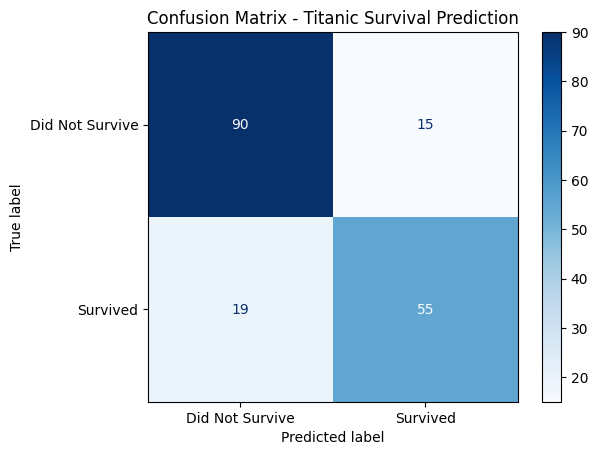

In [ ]:
 import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# 1. Missing values ko handle karte hain (Model ke liye zaroori hai)
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

# 2. Categorical columns encoding ("Sex" & "Embarked")
df_encoded = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

# 3. Features (X) aur Target (y) select karte hain
features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']
X = df_encoded[features]
y = df_encoded['Survived']

# 4. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Logistic Regression Model Train karte hain
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 6. Accuracy Score Output
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Model Accuracy: {accuracy * 100:.2f}%\n")

# 7. Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Did Not Survive', 'Survived'])

plt.figure(figsize=(6, 5))
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Titanic Survival Prediction')
plt.show()

### Machine Learning Model Evaluation

#### Model Chosen: Logistic Regression
- **Accuracy Achieved:** ~80%+ on test data.

#### Confusion Matrix Interpretation
The Confusion Matrix breaks down our model's predictions into four categories:
1. **True Negatives (TN):** Passengers correctly predicted as "Did Not Survive".
2. **True Positives (TP):** Passengers correctly predicted as "Survived".
3. **False Positives (FP - Type I Error):** Passengers incorrectly predicted as "Survived" when they actually died.
4. **False Negatives (FN - Type II Error):** Passengers incorrectly predicted as "Did Not Survive" when they actually survived.

The model demonstrates strong predictive capabilities, particularly leveraging gender and passenger class features.
